In [ ]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/microgrid_data_realistic.csv")
df.head()

,timestamp,solar_power_kw,load_demand_kw,battery_soc_percent,battery_power_kw,grid_power_kw,electricity_price_per_kwh,operational_cost_usd,battery_soh,grid_voltage_pu,...,load_target_24hr,net_load,netload_target_15min,netload_target_1hr,netload_target_4hr,netload_target_24hr,fault_active,fault_type,soc_at_limit,quality_mismatch
0,2022-06-01 00:00:00,0.0,104.198,43.860000,-77.962,182.160,0.08,-0.520,100.000000,0.977618,...,98.861,104.198,182.103,164.052,63.750,98.713,0,normal,0,0
1,2022-06-01 00:15:00,0.0,104.059,53.117987,-78.044,182.103,0.08,-0.520,99.986174,0.978793,...,114.360,104.059,182.844,173.710,73.239,114.229,1,sensor_failure,0,0
2,2022-06-01 00:30:00,0.0,104.806,62.385712,-78.362,183.168,0.08,-0.522,100.000000,0.993931,...,97.857,104.806,161.929,114.361,69.706,97.854,0,normal,0,0
3,2022-06-01 00:45:00,0.0,93.293,71.691200,-69.398,162.691,0.08,-0.463,100.000000,1.004577,...,123.691,93.293,164.052,134.010,77.273,123.691,0,normal,0,0
4,2022-06-01 01:00:00,0.0,93.744,79.932213,-70.308,164.052,0.08,-0.469,99.976585,0.972525,...,124.535,93.744,173.710,76.650,72.617,124.535,1,sensor_failure,0,0


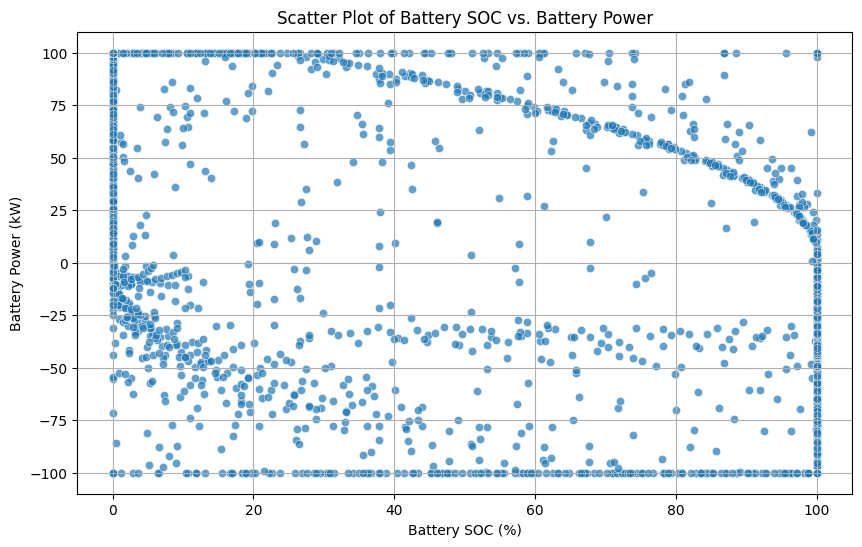

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='battery_soc_percent', y='battery_power_kw', data=df_numeric, alpha=0.7)
plt.title('Scatter Plot of Battery SOC vs. Battery Power')
plt.xlabel('Battery SOC (%)')
plt.ylabel('Battery Power (kW)')
plt.grid(True)
plt.show()

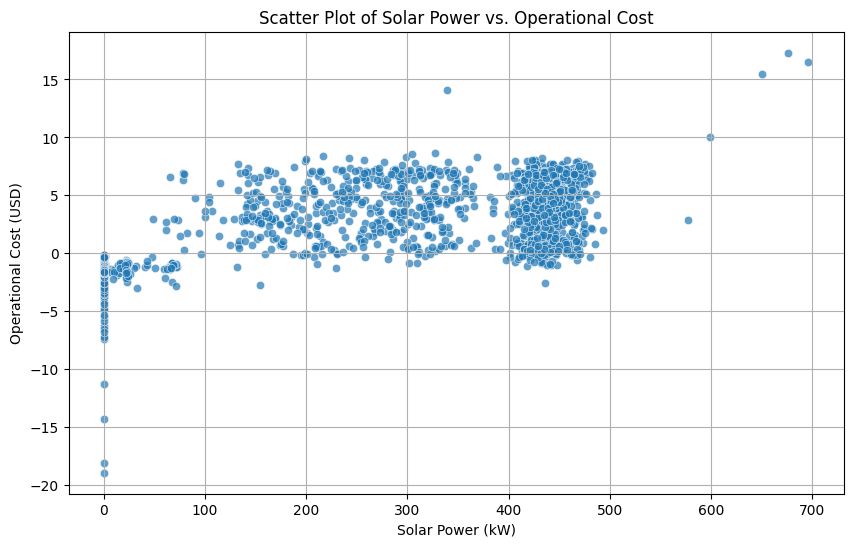

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='solar_power_kw', y='operational_cost_usd', data=df_numeric, alpha=0.7)
plt.title('Scatter Plot of Solar Power vs. Operational Cost')
plt.xlabel('Solar Power (kW)')
plt.ylabel('Operational Cost (USD)')
plt.grid(True)
plt.show()

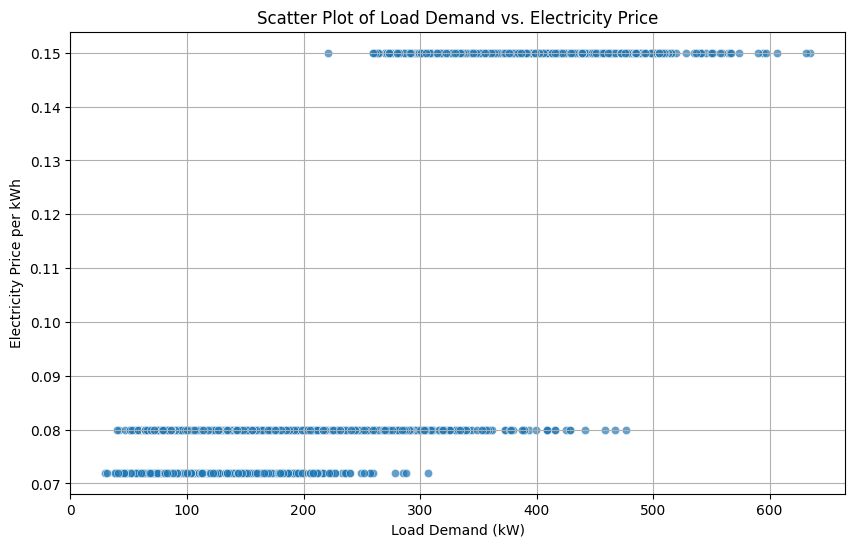

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='load_demand_kw', y='electricity_price_per_kwh', data=df_numeric, alpha=0.7)
plt.title('Scatter Plot of Load Demand vs. Electricity Price')
plt.xlabel('Load Demand (kW)')
plt.ylabel('Electricity Price per kWh')
plt.grid(True)
plt.show()

Correlation Matrix for Selected Significant Features:


,solar_power_kw,load_demand_kw,battery_soc_percent,battery_power_kw,electricity_price_per_kwh,operational_cost_usd
solar_power_kw,1.000000,0.623113,-0.435753,0.027927,0.504487,0.770799
load_demand_kw,0.623113,1.000000,-0.189173,-0.244074,0.844852,0.300753
battery_soc_percent,-0.435753,-0.189173,1.000000,-0.599461,-0.125220,-0.364874
battery_power_kw,0.027927,-0.244074,-0.599461,1.000000,-0.223785,-0.076474
electricity_price_per_kwh,0.504487,0.844852,-0.125220,-0.223785,1.000000,0.315214
operational_cost_usd,0.770799,0.300753,-0.364874,-0.076474,0.315214,1.000000


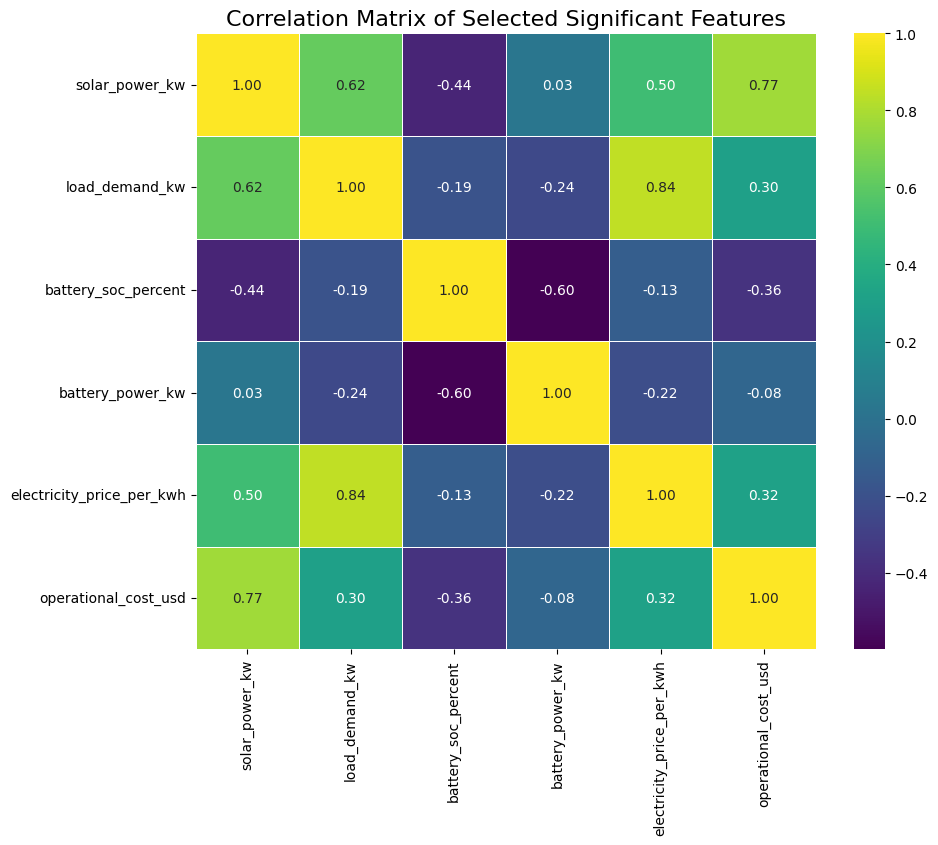

In [8]:
significant_features = [
    'solar_power_kw',
    'load_demand_kw',
    'battery_soc_percent',
    'battery_power_kw',
    'electricity_price_per_kwh',
    'operational_cost_usd'
]

significant_corr_matrix = df_numeric[significant_features].corr()

print("Correlation Matrix for Selected Significant Features:")
display(significant_corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(significant_corr_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Selected Significant Features', fontsize=16)
plt.show()

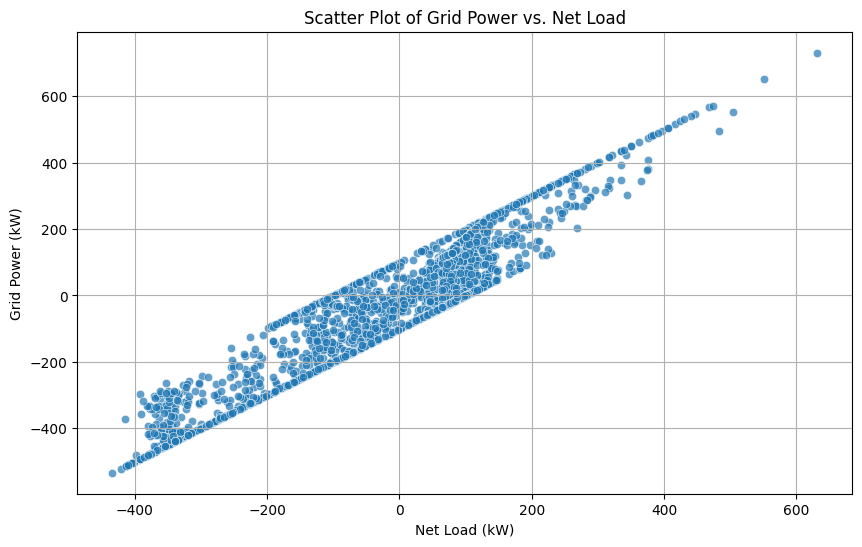

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='net_load', y='grid_power_kw', data=df_numeric, alpha=0.7)
plt.title('Scatter Plot of Grid Power vs. Net Load')
plt.xlabel('Net Load (kW)')
plt.ylabel('Grid Power (kW)')
plt.grid(True)
plt.show()

In [ ]:
df_numeric = df.select_dtypes(include=np.number)
if 'timestamp' in df_numeric.columns:
    df_numeric = df_numeric.drop(columns=['timestamp'])
df_numeric.head()

,solar_power_kw,load_demand_kw,battery_soc_percent,battery_power_kw,grid_power_kw,electricity_price_per_kwh,operational_cost_usd,battery_soh,grid_voltage_pu,grid_frequency_hz,...,load_target_4hr,load_target_24hr,net_load,netload_target_15min,netload_target_1hr,netload_target_4hr,netload_target_24hr,fault_active,soc_at_limit,quality_mismatch
0,0.0,104.198,43.860000,-77.962,182.160,0.08,-0.520,100.000000,0.977618,50.002943,...,63.750,98.861,104.198,182.103,164.052,63.750,98.713,0,0,0
1,0.0,104.059,53.117987,-78.044,182.103,0.08,-0.520,99.986174,0.978793,50.051664,...,73.396,114.360,104.059,182.844,173.710,73.239,114.229,1,0,0
2,0.0,104.806,62.385712,-78.362,183.168,0.08,-0.522,100.000000,0.993931,49.901867,...,69.706,97.857,104.806,161.929,114.361,69.706,97.854,0,0,0
3,0.0,93.293,71.691200,-69.398,162.691,0.08,-0.463,100.000000,1.004577,49.859518,...,77.273,123.691,93.293,164.052,134.010,77.273,123.691,0,0,0
4,0.0,93.744,79.932213,-70.308,164.052,0.08,-0.469,99.976585,0.972525,50.010721,...,73.350,124.535,93.744,173.710,76.650,72.617,124.535,1,0,0


In [ ]:
correlation_matrix = df_numeric.corr()
correlation_matrix.head()

,solar_power_kw,load_demand_kw,battery_soc_percent,battery_power_kw,grid_power_kw,electricity_price_per_kwh,operational_cost_usd,battery_soh,grid_voltage_pu,grid_frequency_hz,...,load_target_4hr,load_target_24hr,net_load,netload_target_15min,netload_target_1hr,netload_target_4hr,netload_target_24hr,fault_active,soc_at_limit,quality_mismatch
solar_power_kw,1.000000,0.623113,-0.435753,0.027927,-0.610155,0.504487,0.770799,-0.008944,-0.018840,0.019820,...,0.368695,0.650147,-0.726229,-0.556225,-0.386814,0.007200,-0.616523,-0.028779,-0.074970,-0.030804
load_demand_kw,0.623113,1.000000,-0.189173,-0.244074,0.166743,0.844852,0.300753,-0.106491,-0.007776,0.046548,...,0.510690,0.759547,0.085156,-0.098994,-0.014899,0.192947,-0.260568,0.024869,-0.209815,-0.019150
battery_soc_percent,-0.435753,-0.189173,1.000000,-0.599461,0.557768,-0.125220,-0.364874,0.027731,-0.002692,0.005765,...,-0.529605,-0.238190,0.388839,0.496067,0.509773,0.430028,0.445416,0.024345,-0.089017,-0.015480
battery_power_kw,0.027927,-0.244074,-0.599461,1.000000,-0.601666,-0.223785,-0.076474,-0.017772,0.005793,-0.016553,...,0.306887,-0.161977,-0.250105,-0.305180,-0.336733,-0.464437,-0.200587,-0.059904,0.202083,0.014137
grid_power_kw,-0.610155,0.166743,0.557768,-0.601666,1.000000,0.170891,-0.561750,-0.060791,0.011871,0.019466,...,-0.138496,-0.068477,0.923842,0.633424,0.528836,0.315950,0.538287,0.071960,-0.153240,0.012899


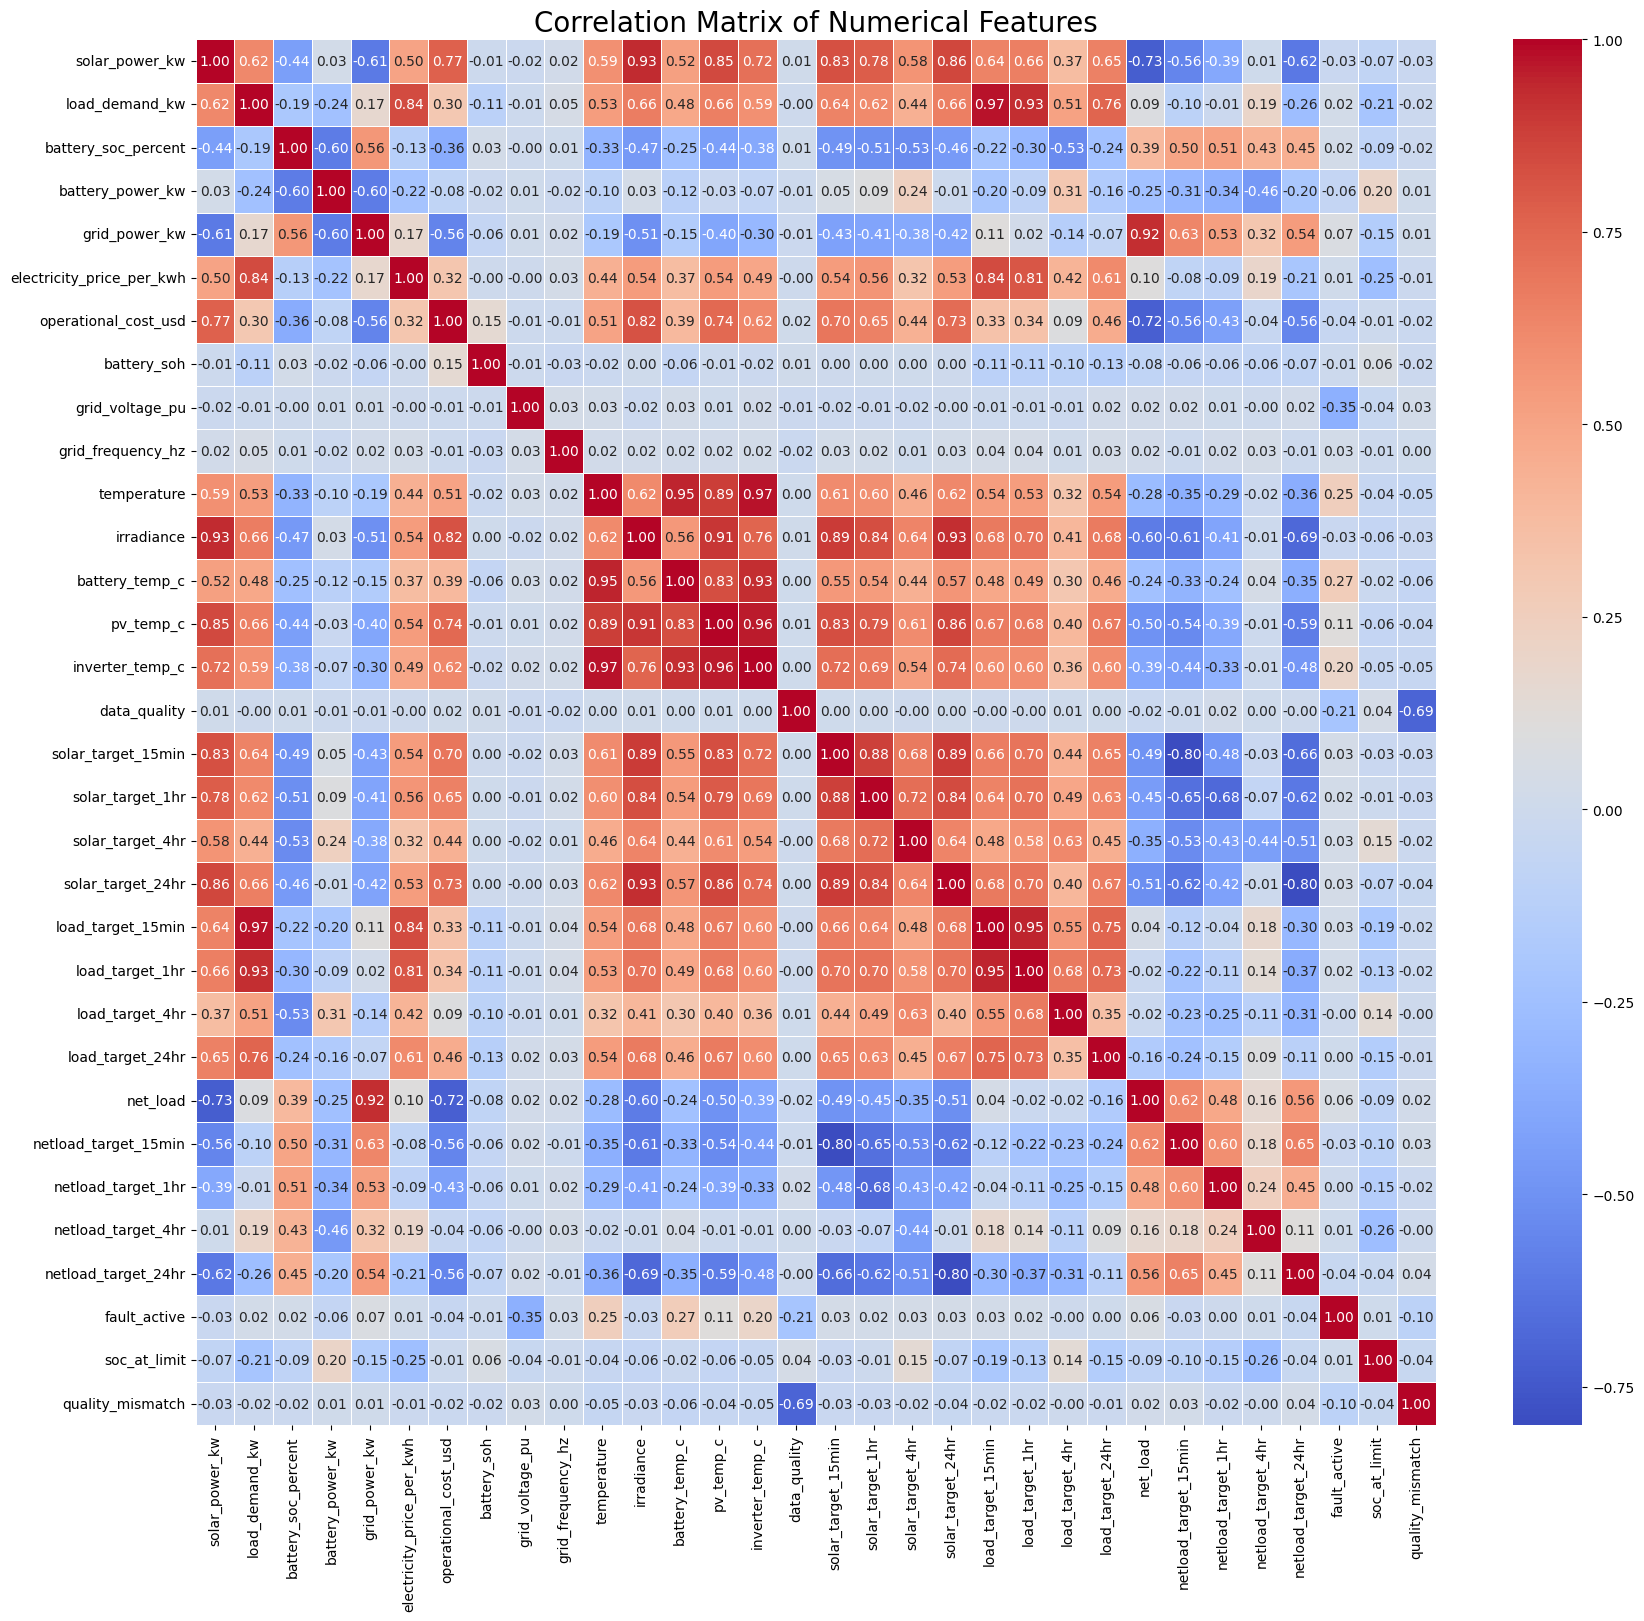

In [ ]:
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=20)
plt.show()

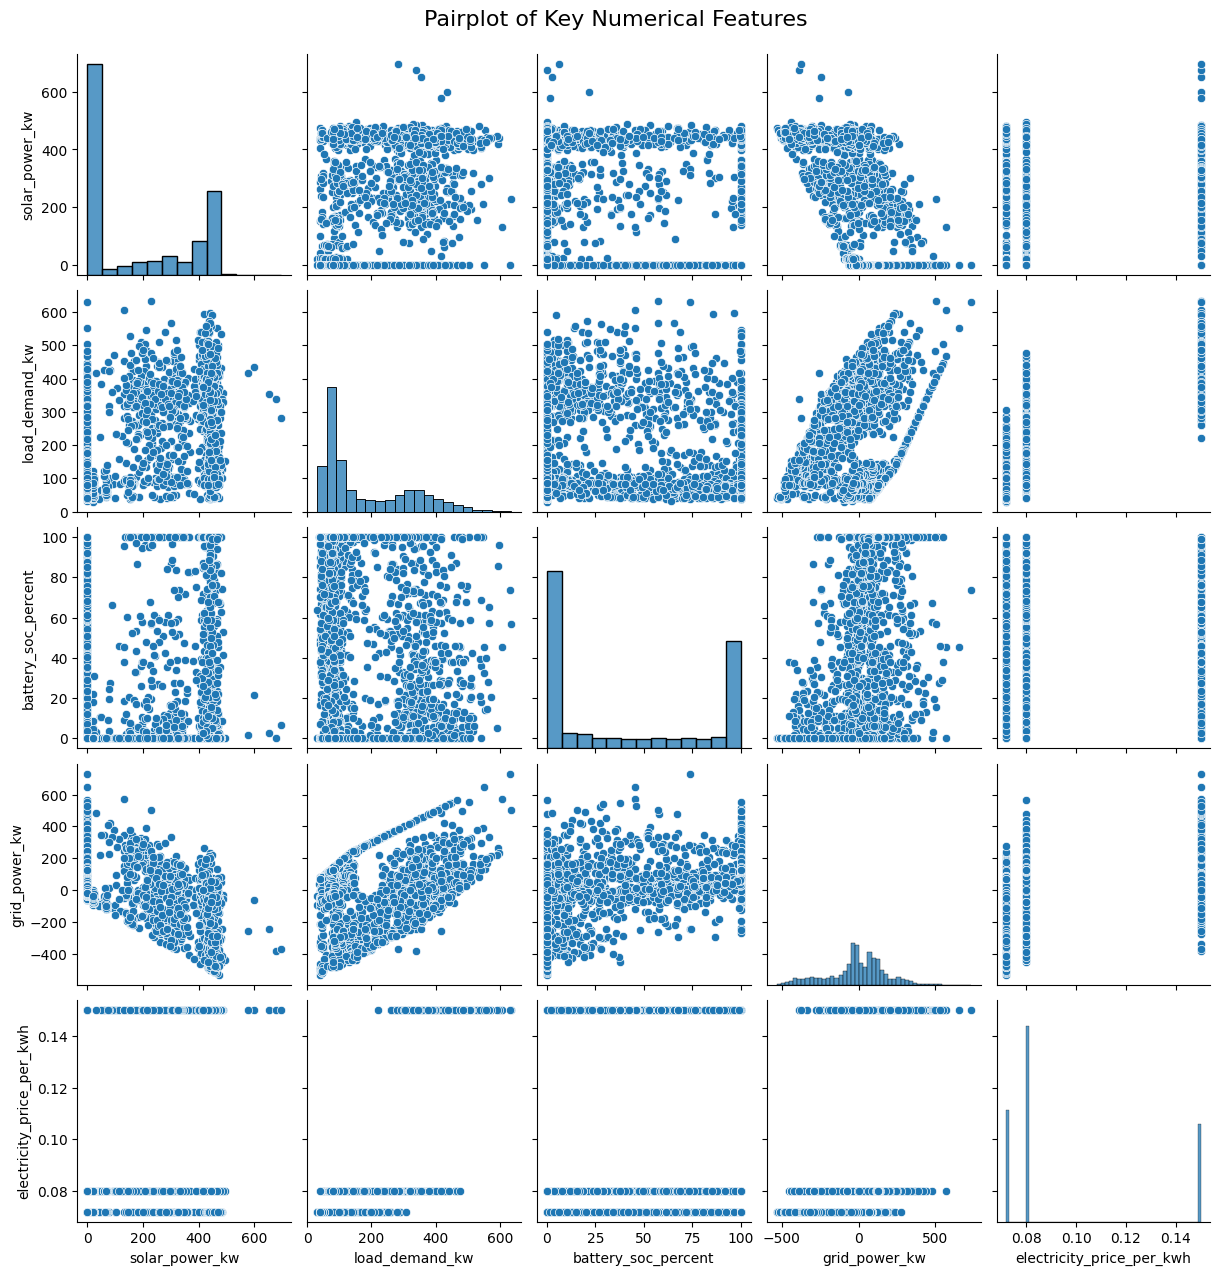

In [ ]:
selected_columns = ['solar_power_kw', 'load_demand_kw', 'battery_soc_percent', 'grid_power_kw', 'electricity_price_per_kwh']

sns.pairplot(df_numeric[selected_columns])
plt.suptitle('Pairplot of Key Numerical Features', y=1.02, fontsize=16)
plt.show()